In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.covariance import LedoitWolf
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def find_file(name):
    for d in [Path.cwd(), Path("/content")]:
        if (d / name).exists():
            return str(d / name)
    return name

RETURNS_FILE = find_file("daily_returns.xlsx")
CATEGORIES_FILE = find_file("stock_categories.xlsx")

TRADING_DAYS = 252
RF_ANNUAL = 0.065
RF_DAILY = (1 + RF_ANNUAL) ** (1/TRADING_DAYS) - 1

print(f"Configuration:")
print(f"  Returns file:   {RETURNS_FILE}")
print(f"  Categories file:{CATEGORIES_FILE}")
print(f"  Trading Days: {TRADING_DAYS}")
print(f"  Risk-Free Rate (Annual): {RF_ANNUAL:.2%}")
print(f"  Risk-Free Rate (Daily): {RF_DAILY:.4%}")

Configuration:
  Returns file:   /Users/dharunpathitamilselvan/Documents/Sem 6/DA6701/DA6701 DSAI in Finance/Assignment 1/daily_returns.xlsx
  Categories file:/Users/dharunpathitamilselvan/Documents/Sem 6/DA6701/DA6701 DSAI in Finance/Assignment 1/stock_categories.xlsx
  Trading Days: 252
  Risk-Free Rate (Annual): 6.50%
  Risk-Free Rate (Daily): 0.0250%


In [2]:
print("="*80)
print("DATA LOADING AND VALIDATION")
print("="*80)

returns_raw = pd.read_excel(RETURNS_FILE)
categories = pd.read_excel(CATEGORIES_FILE)

print(f"\n1. Data Shapes:")
print(f"   Returns: {returns_raw.shape}")
print(f"   Categories: {categories.shape}")

print(f"\n2. Sector Distribution:")
sector_counts = categories['Category'].value_counts()
print(sector_counts)
print(f"\n   Total unique sectors: {categories['Category'].nunique()}")

print(f"\n3. Data Quality Checks:")
print(f"   Missing values in returns: {returns_raw.isnull().sum().sum()}")
print(f"   Date range: {returns_raw['Date'].min()} to {returns_raw['Date'].max()}")
print(f"   Number of trading days: {len(returns_raw)}")

print(f"\n4. Sample Data:")
display(returns_raw.head(3))
display(categories.head(3))

DATA LOADING AND VALIDATION

1. Data Shapes:
   Returns: (739, 31)
   Categories: (30, 3)

2. Sector Distribution:
Category
Banking & Finance     3
Information Tech      3
Automobiles           3
Consumer Goods        3
Energy & Power        3
Pharmaceuticals       3
Metals & Mining       3
Construction/Infra    3
Telecommunications    3
Retail/E-commerce     3
Name: count, dtype: int64

   Total unique sectors: 10

3. Data Quality Checks:
   Missing values in returns: 0
   Date range: 2023-02-02 to 2026-01-30
   Number of trading days: 739

4. Sample Data:


,Date,HDFCBANK,ICICIBANK,SBIN,TCS,INFY,HCLTECH,BAJAJ-AUTO,M&M,MARUTI,...,HINDALCO,LT,ULTRACEMCO,ADANIPORTS,BHARTIARTL,TATACOMM,INDUSTOWER,TITAN,DMART,TRENT
0,2023-02-02,-1.4869,1.1734,0.1422,1.5271,2.1049,1.5458,-0.5405,0.0259,1.1552,...,-0.5237,-0.0303,0.3676,-6.6041,1.1247,0.9439,-1.1777,-1.6113,-1.3643,-0.4441
1,2023-02-03,3.4584,0.6877,3.0487,0.6329,0.9882,-0.3001,1.6316,2.6324,0.8134,...,-1.2355,1.0094,0.3007,7.8711,1.9479,1.0463,0.7010,6.7155,-0.9292,2.0692
2,2023-02-06,-0.4250,-1.1692,0.2205,-0.6418,-1.8476,-0.0392,-0.0896,-0.8646,-0.3836,...,-2.6760,-0.4823,-0.8617,9.3415,-0.4603,2.5724,12.8089,-0.2071,-0.8313,-0.4492


,Category,Symbol,Company Name
0,Banking & Finance,HDFCBANK,HDFC Bank
1,Banking & Finance,ICICIBANK,ICICI Bank
2,Banking & Finance,SBIN,State Bank of India


In [3]:
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

returns_raw['Date'] = pd.to_datetime(returns_raw['Date'])
returns_raw = returns_raw.sort_values('Date').set_index('Date')

all_symbols = categories['Symbol'].astype(str).unique().tolist()
available_cols = [col for col in returns_raw.columns if col in all_symbols]

print(f"\n1. Symbol Matching:")
print(f"   Symbols in categories: {len(all_symbols)}")
print(f"   Symbols in returns data: {len(available_cols)}")
print(f"   Missing symbols: {set(all_symbols) - set(available_cols)}")

returns_pct = returns_raw[available_cols].copy()
returns_decimal = returns_pct / 100.0

print(f"\n2. Missing Value Treatment:")
print(f"   Missing values before: {returns_decimal.isnull().sum().sum()}")
returns_clean = returns_decimal.dropna(how='any')
print(f"   Missing values after dropna: {returns_clean.isnull().sum().sum()}")
print(f"   Rows dropped: {len(returns_decimal) - len(returns_clean)}")
print(f"   Final data shape: {returns_clean.shape}")

R = returns_clean.copy()

print(f"\n3. Return Statistics (Daily, %):")
stats_summary = pd.DataFrame({
    'Mean (%)': R.mean() * 100,
    'Std (%)': R.std() * 100,
    'Min (%)': R.min() * 100,
    'Max (%)': R.max() * 100
}).round(3)
display(stats_summary.head(10))


DATA PREPROCESSING

1. Symbol Matching:
   Symbols in categories: 30
   Symbols in returns data: 30
   Missing symbols: set()

2. Missing Value Treatment:
   Missing values before: 0
   Missing values after dropna: 0
   Rows dropped: 0
   Final data shape: (739, 30)

3. Return Statistics (Daily, %):


,Mean (%),Std (%),Min (%),Max (%)
HDFCBANK,0.030,1.155,-8.436,4.629
ICICIBANK,0.073,1.110,-7.634,4.716
SBIN,0.115,1.435,-14.404,9.068
TCS,0.007,1.243,-4.219,6.633
INFY,0.031,1.505,-9.423,7.934
HCLTECH,0.081,1.440,-8.839,7.710
BAJAJ-AUTO,0.146,1.540,-12.891,6.720
M&M,0.144,1.727,-6.614,6.531
MARUTI,0.081,1.269,-4.130,8.751
HINDUNILVR,0.003,1.148,-7.400,5.960



STOCK SELECTION: HIERARCHICAL RISK PARITY (HRP)

Correlation matrix of all stocks: (30, 30)


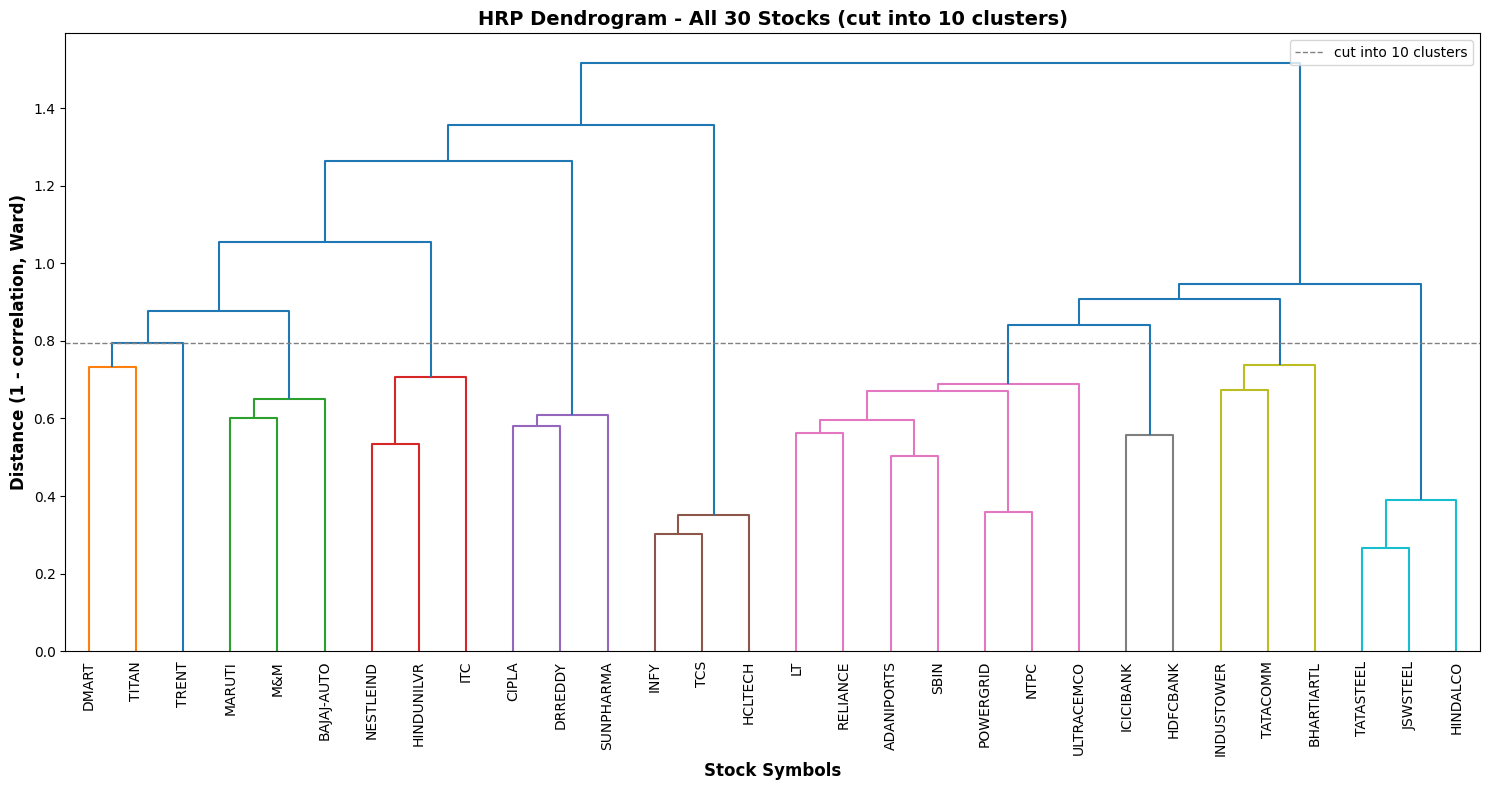


Tree cut into 10 clusters:
   Cluster  1: ['JSWSTEEL', 'TATASTEEL', 'HINDALCO']
   Cluster  2: ['BHARTIARTL', 'TATACOMM', 'INDUSTOWER']
   Cluster  3: ['HDFCBANK', 'ICICIBANK']
   Cluster  4: ['SBIN', 'RELIANCE', 'NTPC', 'POWERGRID', 'LT', 'ULTRACEMCO', 'ADANIPORTS']
   Cluster  5: ['TCS', 'INFY', 'HCLTECH']
   Cluster  6: ['SUNPHARMA', 'DRREDDY', 'CIPLA']
   Cluster  7: ['HINDUNILVR', 'ITC', 'NESTLEIND']
   Cluster  8: ['BAJAJ-AUTO', 'M&M', 'MARUTI']
   Cluster  9: ['TITAN', 'DMART']
   Cluster 10: ['TRENT']

HRP-Selected Stocks (one representative per cluster):



,Cluster,ClusterSize,Symbol,Sector,Sharpe,AvgAbsCorrelation,AnnReturn(%),AnnVol(%)
0,2,3,BHARTIARTL,Telecommunications,1.414787,0.242085,34.712267,20.083584
1,8,3,BAJAJ-AUTO,Automobiles,1.242285,0.223687,36.669990,24.448276
2,10,1,TRENT,Retail/E-commerce,1.104246,0.212914,44.945752,34.998970
3,4,7,ADANIPORTS,Construction/Infra,1.024936,0.277158,42.941209,35.751427
4,1,3,HINDALCO,Metals & Mining,0.811131,0.270862,29.350532,28.419920
5,3,2,ICICIBANK,Banking & Finance,0.685321,0.236895,18.373664,17.620051
6,9,2,TITAN,Retail/E-commerce,0.683629,0.226862,20.480166,20.745012
7,6,3,SUNPHARMA,Pharmaceuticals,0.638968,0.209995,18.137385,18.528505
8,5,3,HCLTECH,Information Tech,0.612694,0.225634,20.300970,22.854332
9,7,3,NESTLEIND,Consumer Goods,0.417486,0.190527,14.082333,18.645076



Selection Summary:
   Total stocks selected: 10
   Clusters represented:  10 / 10
   Sectors covered:       9
   Average Sharpe Ratio:  0.864
   Avg |correlation|:     0.232
   Selected universe:     ['BHARTIARTL', 'BAJAJ-AUTO', 'TRENT', 'ADANIPORTS', 'HINDALCO', 'ICICIBANK', 'TITAN', 'SUNPHARMA', 'HCLTECH', 'NESTLEIND']


In [4]:
print("\n" + "="*80)
print("STOCK SELECTION: HIERARCHICAL RISK PARITY (HRP)")
print("="*80)

sym_to_sector = categories.set_index('Symbol')['Category'].to_dict()

corr_matrix_all = R.corr()
print(f"\nCorrelation matrix of all stocks: {corr_matrix_all.shape}")

dissimilarity_matrix = 1 - corr_matrix_all
dist_condensed = squareform(dissimilarity_matrix, checks=False)
linked_matrix = linkage(dist_condensed, method='ward')

N_CLUSTERS = 10
color_thresh = linked_matrix[-(N_CLUSTERS - 1), 2]

plt.figure(figsize=(15, 8))
dendrogram(
    linked_matrix,
    orientation='top',
    labels=corr_matrix_all.columns.tolist(),
    distance_sort='descending',
    color_threshold=color_thresh,
    show_leaf_counts=True
)
plt.axhline(y=color_thresh, color='grey', linestyle='--', linewidth=1,
            label=f'cut into {N_CLUSTERS} clusters')
plt.title('HRP Dendrogram - All 30 Stocks (cut into 10 clusters)',
          fontsize=14, fontweight='bold')
plt.xlabel('Stock Symbols', fontsize=12, fontweight='bold')
plt.ylabel('Distance (1 - correlation, Ward)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

cluster_labels = fcluster(linked_matrix, t=N_CLUSTERS, criterion='maxclust')
clusters = {}
for sym, lab in zip(corr_matrix_all.columns, cluster_labels):
    clusters.setdefault(int(lab), []).append(sym)

print(f"\nTree cut into {len(clusters)} clusters:")
for lab in sorted(clusters):
    print(f"   Cluster {lab:2d}: {clusters[lab]}")

abs_corr = corr_matrix_all.abs()
selection_results = []
for lab in sorted(clusters):
    members = clusters[lab]
    best_sym, best_sharpe = None, -np.inf
    for stock in members:
        mean_ret = R[stock].mean()
        std_ret = R[stock].std()
        sharpe = (mean_ret - RF_DAILY) / std_ret * np.sqrt(TRADING_DAYS) if std_ret > 0 else -np.inf
        if sharpe > best_sharpe:
            best_sharpe, best_sym = sharpe, stock
    s = best_sym
    other = [x for x in corr_matrix_all.columns if x != s]
    selection_results.append({
        'Cluster': lab,
        'ClusterSize': len(members),
        'Symbol': s,
        'Sector': sym_to_sector.get(s, 'NA'),
        'Sharpe': (R[s].mean() - RF_DAILY) / R[s].std() * np.sqrt(TRADING_DAYS),
        'AvgAbsCorrelation': abs_corr.loc[s, other].mean(),
        'AnnReturn(%)': R[s].mean() * TRADING_DAYS * 100,
        'AnnVol(%)': R[s].std() * np.sqrt(TRADING_DAYS) * 100,
    })

selected_stocks_df = (pd.DataFrame(selection_results)
                      .sort_values('Sharpe', ascending=False)
                      .reset_index(drop=True))
selected_symbols = selected_stocks_df['Symbol'].tolist()

print("\nHRP-Selected Stocks (one representative per cluster):\n")
display(selected_stocks_df)

print(f"\nSelection Summary:")
print(f"   Total stocks selected: {len(selected_symbols)}")
print(f"   Clusters represented:  {selected_stocks_df['Cluster'].nunique()} / {N_CLUSTERS}")
print(f"   Sectors covered:       {selected_stocks_df['Sector'].nunique()}")
print(f"   Average Sharpe Ratio:  {selected_stocks_df['Sharpe'].mean():.3f}")
print(f"   Avg |correlation|:     {selected_stocks_df['AvgAbsCorrelation'].mean():.3f}")
print(f"   Selected universe:     {selected_symbols}")


CORRELATION ANALYSIS - SELECTED 10 STOCKS


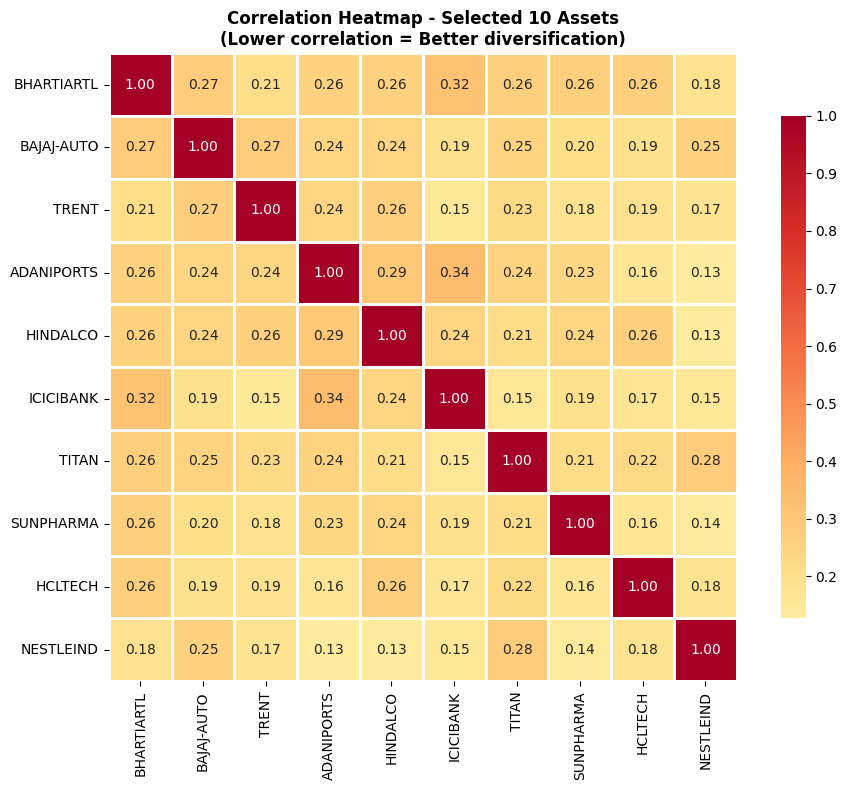


1. Correlation Statistics:
   Mean correlation: nan
   Median correlation: nan
   Min correlation: nan
   Max correlation: nan
   Std correlation: nan

2. Least Correlated Pairs (Best for diversification):


,Stock1,Stock2,Correlation
34,HINDALCO,NESTLEIND,0.126338
29,ADANIPORTS,NESTLEIND,0.132656
43,SUNPHARMA,NESTLEIND,0.138884
19,TRENT,ICICIBANK,0.149810
38,ICICIBANK,NESTLEIND,0.152026



3. Most Correlated Pairs:


,Stock1,Stock2,Correlation
0,BHARTIARTL,BAJAJ-AUTO,0.274561
41,TITAN,NESTLEIND,0.280523
24,ADANIPORTS,HINDALCO,0.291031
4,BHARTIARTL,ICICIBANK,0.315037
25,ADANIPORTS,ICICIBANK,0.339775


In [5]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS - SELECTED 10 STOCKS")
print("="*80)

R_selected = R[selected_symbols].copy()
corr_selected = R_selected.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_selected,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Selected 10 Assets\n(Lower correlation = Better diversification)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n1. Correlation Statistics:")
mask = np.triu(np.ones_like(corr_selected), k=1).astype(bool)
corr_values = corr_selected.where(mask).stack().values

print(f"   Mean correlation: {corr_values.mean():.3f}")
print(f"   Median correlation: {np.median(corr_values):.3f}")
print(f"   Min correlation: {corr_values.min():.3f}")
print(f"   Max correlation: {corr_values.max():.3f}")
print(f"   Std correlation: {corr_values.std():.3f}")

corr_pairs = []
for i in range(len(selected_symbols)):
    for j in range(i+1, len(selected_symbols)):
        corr_pairs.append({
            'Stock1': selected_symbols[i],
            'Stock2': selected_symbols[j],
            'Correlation': corr_selected.iloc[i, j]
        })
corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation')

print(f"\n2. Least Correlated Pairs (Best for diversification):")
display(corr_pairs_df.head(5))

print(f"\n3. Most Correlated Pairs:")
display(corr_pairs_df.tail(5))

In [6]:
print("\n" + "="*80)
print("COVARIANCE MATRIX ESTIMATION (LEDOIT-WOLF)")
print("="*80)

mu_daily = R_selected.mean().values
mu_annual = mu_daily * TRADING_DAYS

lw_estimator = LedoitWolf()
lw_estimator.fit(R_selected.values)

cov_daily = pd.DataFrame(
    lw_estimator.covariance_,
    index=R_selected.columns,
    columns=R_selected.columns
)
cov_annual = cov_daily * TRADING_DAYS

sample_cov_daily = R_selected.cov()
sample_cov_annual = sample_cov_daily * TRADING_DAYS

cond_lw = np.linalg.cond(cov_annual.values)
cond_sample = np.linalg.cond(sample_cov_annual.values)

print(f"\nShrinkage Intensity: {lw_estimator.shrinkage_:.4f}")
print(f"\nCovariance (annualized):")
print(f"   Ledoit-Wolf - Mean: {cov_annual.values.mean():.6f}, Max: {cov_annual.values.max():.6f}")
print(f"   Sample      - Mean: {sample_cov_annual.values.mean():.6f}, Max: {sample_cov_annual.values.max():.6f}")
print(f"\nCondition Number:")
print(f"   Ledoit-Wolf: {cond_lw:.2f}")
print(f"   Sample:      {cond_sample:.2f}")

mu = mu_annual
cov = cov_annual.values


COVARIANCE MATRIX ESTIMATION (LEDOIT-WOLF)

Shrinkage Intensity: 0.0567

Covariance (annualized):
   Ledoit-Wolf - Mean: 0.017273, Max: 0.123953
   Sample      - Mean: 0.017960, Max: 0.127816

Condition Number:
   Ledoit-Wolf: 8.38
   Sample:      9.64


In [7]:
print("\n" + "="*80)
print("PORTFOLIO OPTIMIZATION")
print("="*80)

def portfolio_return(weights, mu):
    return float(weights @ mu)

def portfolio_volatility(weights, cov):
    return float(np.sqrt(weights @ cov @ weights))

def portfolio_sharpe(weights, mu, cov, rf):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return (ret - rf) / vol if vol > 1e-9 else -np.inf

def optimize_gmv(cov_matrix):
    n = cov_matrix.shape[0]

    def objective(w):
        return w @ cov_matrix @ w

    def gradient(w):
        return 2 * cov_matrix @ w

    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n

    result = minimize(
        objective, w0,
        method='SLSQP',
        jac=gradient,
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    if not result.success:
        print(f"   WARNING: Optimization may not have converged fully")
        print(f"   Message: {result.message}")

    return result.x, result.success

w_gmv_array, gmv_success = optimize_gmv(cov)
w_gmv = pd.Series(w_gmv_array, index=R_selected.columns, name='GMV')

print(f"\n1. Global Minimum Variance (GMV) Portfolio:")
print(f"   Status: {'Success' if gmv_success else 'Warning'}")
print(f"   GMV Return: {portfolio_return(w_gmv_array, mu):.2%}")
print(f"   GMV Volatility: {portfolio_volatility(w_gmv_array, cov):.2%}")
print(f"   GMV Sharpe: {portfolio_sharpe(w_gmv_array, mu, cov, RF_ANNUAL):.3f}")

def optimize_max_sharpe(mu_vec, cov_matrix, rf, n_starts=20):
    n = len(mu_vec)

    def objective(w):
        vol = np.sqrt(w @ cov_matrix @ w)
        if vol < 1e-9:
            return 1e10
        return -((w @ mu_vec - rf) / vol)

    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0.0, 1.0)] * n

    best_result = None
    best_sharpe = -np.inf

    rng = np.random.default_rng(42)
    starting_points = [np.ones(n)/n] + [rng.dirichlet(np.ones(n)) for _ in range(n_starts)]

    for w0 in starting_points:
        result = minimize(
            objective, w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 1000}
        )
        if result.success:
            sharpe = -result.fun
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_result = result

    if best_result is None:
        raise RuntimeError("Max Sharpe optimization failed on all starting points")

    return best_result.x, best_result.success, best_sharpe

w_msr_array, msr_success, msr_sharpe = optimize_max_sharpe(mu, cov, RF_ANNUAL, n_starts=25)
w_msr = pd.Series(w_msr_array, index=R_selected.columns, name='MaxSharpe')

print(f"\n2. Maximum Sharpe Ratio (Tangency) Portfolio:")
print(f"   Status: {'Success' if msr_success else 'Warning'}")
print(f"   MSR Return: {portfolio_return(w_msr_array, mu):.2%}")
print(f"   MSR Volatility: {portfolio_volatility(w_msr_array, cov):.2%}")
print(f"   MSR Sharpe: {portfolio_sharpe(w_msr_array, mu, cov, RF_ANNUAL):.3f}")

print("\n3. Equal Weight Portfolio (Benchmark):")
w_eq_array = np.ones(len(R_selected.columns)) / len(R_selected.columns)
w_eq = pd.Series(w_eq_array, index=R_selected.columns, name='EqualWeight')

print(f"   EW Return: {portfolio_return(w_eq_array, mu):.2%}")
print(f"   EW Volatility: {portfolio_volatility(w_eq_array, cov):.2%}")
print(f"   EW Sharpe: {portfolio_sharpe(w_eq_array, mu, cov, RF_ANNUAL):.3f}")

weights_comparison = pd.concat([w_gmv, w_msr, w_eq], axis=1)
print("\n4. Weight Comparison:")
display(weights_comparison.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=0))


PORTFOLIO OPTIMIZATION

1. Global Minimum Variance (GMV) Portfolio:
   Status: Success
   GMV Return: 20.44%
   GMV Volatility: 11.14%
   GMV Sharpe: 1.251

2. Maximum Sharpe Ratio (Tangency) Portfolio:
   Status: Success
   MSR Return: 37.08%
   MSR Volatility: 16.50%
   MSR Sharpe: 1.853

3. Equal Weight Portfolio (Benchmark):
   EW Return: 28.00%
   EW Volatility: 13.14%
   EW Sharpe: 1.636

4. Weight Comparison:


,GMV,MaxSharpe,EqualWeight
BHARTIARTL,0.0886,0.4059,0.1000
BAJAJ-AUTO,0.0495,0.2514,0.1000
TRENT,0.0013,0.1547,0.1000
ADANIPORTS,0.0000,0.1169,0.1000
HINDALCO,0.0153,0.0416,0.1000
ICICIBANK,0.2304,0.0003,0.1000
TITAN,0.1102,0.0034,0.1000
SUNPHARMA,0.2008,0.0100,0.1000
HCLTECH,0.1017,0.0157,0.1000
NESTLEIND,0.2024,0.0000,0.1000



EFFICIENT FRONTIER - MONTE CARLO SIMULATION



Total portfolios: 120,010
Return range: 14.08% to 44.95%
Volatility range: 11.19% to 35.21%
Sharpe range: 0.40 to 1.84

GMV Portfolio:        Return: 20.44%, Volatility: 11.14%, Sharpe: 1.251
Max Sharpe Portfolio: Return: 37.08%, Volatility: 16.50%, Sharpe: 1.853


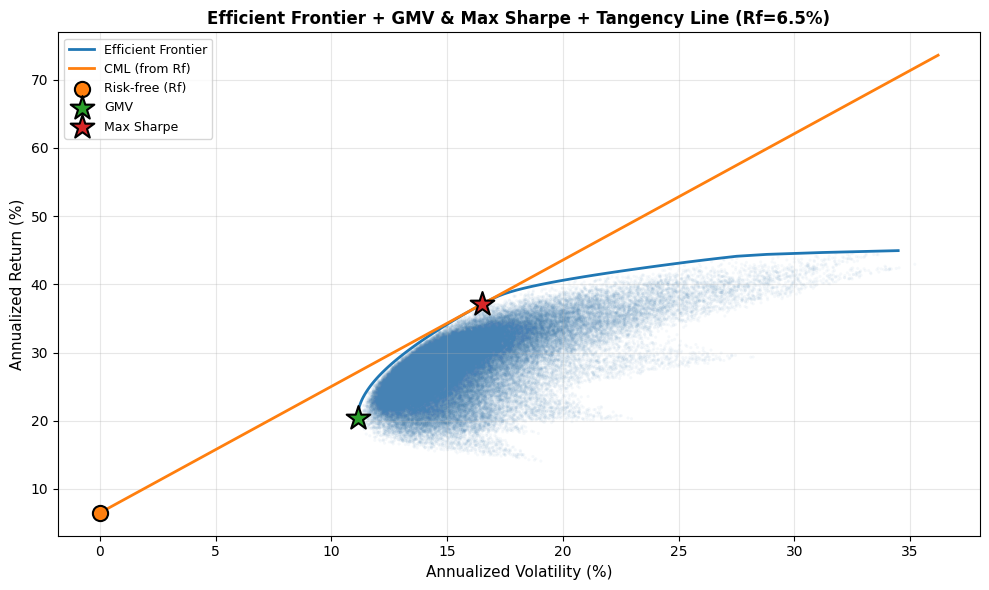

,Portfolio,Return,Volatility,Sharpe Ratio
0,GMV,20.44%,11.14%,1.251
1,Max Sharpe,37.08%,16.50%,1.853


In [8]:
print("\n" + "="*80)
print("EFFICIENT FRONTIER - MONTE CARLO SIMULATION")
print("="*80)

rng = np.random.default_rng(42)

N1, N2 = 70000, 50000
alpha1, alpha2 = 1.0, 0.25

W1 = rng.dirichlet(np.ones(len(mu)) * alpha1, size=N1)
W2 = rng.dirichlet(np.ones(len(mu)) * alpha2, size=N2)
W_corners = np.eye(len(mu))

weights_mc = np.vstack([W1, W2, W_corners])

returns_mc = weights_mc @ mu
vols_mc = np.sqrt(np.einsum('ij,jk,ik->i', weights_mc, cov, weights_mc))
sharpes_mc = (returns_mc - RF_ANNUAL) / (vols_mc + 1e-12)

print(f"\nTotal portfolios: {len(weights_mc):,}")
print(f"Return range: {returns_mc.min():.2%} to {returns_mc.max():.2%}")
print(f"Volatility range: {vols_mc.min():.2%} to {vols_mc.max():.2%}")
print(f"Sharpe range: {sharpes_mc.min():.2f} to {sharpes_mc.max():.2f}")

n = len(mu)
bounds = [(0.0, 1.0)] * n
cons_sum = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
w0 = np.ones(n) / n

def pret(w): return float(w @ mu)
def pvar(w): return float(w @ cov @ w)
def pvol(w): return float(np.sqrt(pvar(w)))
def psharpe(w):
    v = pvol(w)
    return (pret(w) - RF_ANNUAL) / (v + 1e-12)

res_gmv = minimize(pvar, w0, method="SLSQP", bounds=bounds, constraints=[cons_sum],
                   options={"maxiter": 6000, "ftol": 1e-14})
w_gmv_array = res_gmv.x
gmv_ret = pret(w_gmv_array)
gmv_vol = pvol(w_gmv_array)
gmv_sharpe = psharpe(w_gmv_array)

res_ms = minimize(lambda w: -psharpe(w), w0, method="SLSQP", bounds=bounds, constraints=[cons_sum],
                  options={"maxiter": 6000, "ftol": 1e-14})
w_msr_array = res_ms.x
ms_ret = pret(w_msr_array)
ms_vol = pvol(w_msr_array)
ms_sharpe = psharpe(w_msr_array)

print(f"\nGMV Portfolio:        Return: {gmv_ret:.2%}, Volatility: {gmv_vol:.2%}, Sharpe: {gmv_sharpe:.3f}")
print(f"Max Sharpe Portfolio: Return: {ms_ret:.2%}, Volatility: {ms_vol:.2%}, Sharpe: {ms_sharpe:.3f}")

r_max = float(np.max(mu))
targets = np.linspace(gmv_ret, r_max, 90)

front_vol = [gmv_vol]
front_ret = [gmv_ret]
w_prev = w_gmv_array.copy()

for t in targets[1:]:
    cons = [
        cons_sum,
        {"type": "eq", "fun": lambda w, t=t: (w @ mu) - t}
    ]
    res = minimize(pvar, w_prev, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 8000, "ftol": 1e-14})
    if res.success:
        w_prev = res.x
        front_vol.append(pvol(res.x))
        front_ret.append(pret(res.x))

frontier_df = pd.DataFrame({"vol": front_vol, "ret": front_ret}).sort_values("vol")
frontier_df["ret"] = np.maximum.accumulate(frontier_df["ret"].values)

cml_slope = ms_sharpe
cml_vols = np.linspace(0, max(frontier_df["vol"].max(), ms_vol) * 1.05, 300)
cml_rets = RF_ANNUAL + cml_slope * cml_vols

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(vols_mc * 100, returns_mc * 100,
           s=5, alpha=0.05, color='steelblue', edgecolors='none')

ax.plot(frontier_df["vol"] * 100, frontier_df["ret"] * 100,
        color='#1f77b4', linewidth=2, label='Efficient Frontier', zorder=5)

ax.plot(cml_vols * 100, cml_rets * 100,
        color='#ff7f0e', linewidth=2, label='CML (from Rf)', zorder=5)

ax.scatter([0], [RF_ANNUAL * 100],
           marker='o', s=120, c='#ff7f0e',
           edgecolors='black', linewidths=1.5, label='Risk-free (Rf)', zorder=6)

ax.scatter([gmv_vol * 100], [gmv_ret * 100],
           marker='*', s=320, c='#2ca02c',
           edgecolors='black', linewidths=1.5, label='GMV', zorder=6)

ax.scatter([ms_vol * 100], [ms_ret * 100],
           marker='*', s=320, c='#d62728',
           edgecolors='black', linewidths=1.5, label='Max Sharpe', zorder=6)

ax.set_xlabel('Annualized Volatility (%)', fontsize=11)
ax.set_ylabel('Annualized Return (%)', fontsize=11)
ax.set_title(f'Efficient Frontier + GMV & Max Sharpe + Tangency Line (Rf={RF_ANNUAL:.1%})',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Portfolio': ['GMV', 'Max Sharpe'],
    'Return': [gmv_ret, ms_ret],
    'Volatility': [gmv_vol, ms_vol],
    'Sharpe Ratio': [gmv_sharpe, ms_sharpe]
})

summary['Return'] = summary['Return'].apply(lambda x: f'{x:.2%}')
summary['Volatility'] = summary['Volatility'].apply(lambda x: f'{x:.2%}')
summary['Sharpe Ratio'] = summary['Sharpe Ratio'].apply(lambda x: f'{x:.3f}')

display(summary)


WEIGHT ATTRIBUTION ANALYSIS

Herfindahl-Hirschman Index (HHI):
   GMV            : 0.1674 (Effective N = 5.98)
   MaxSharpe      : 0.2677 (Effective N = 3.74)
   EqualWeight    : 0.1000 (Effective N = 10.00)


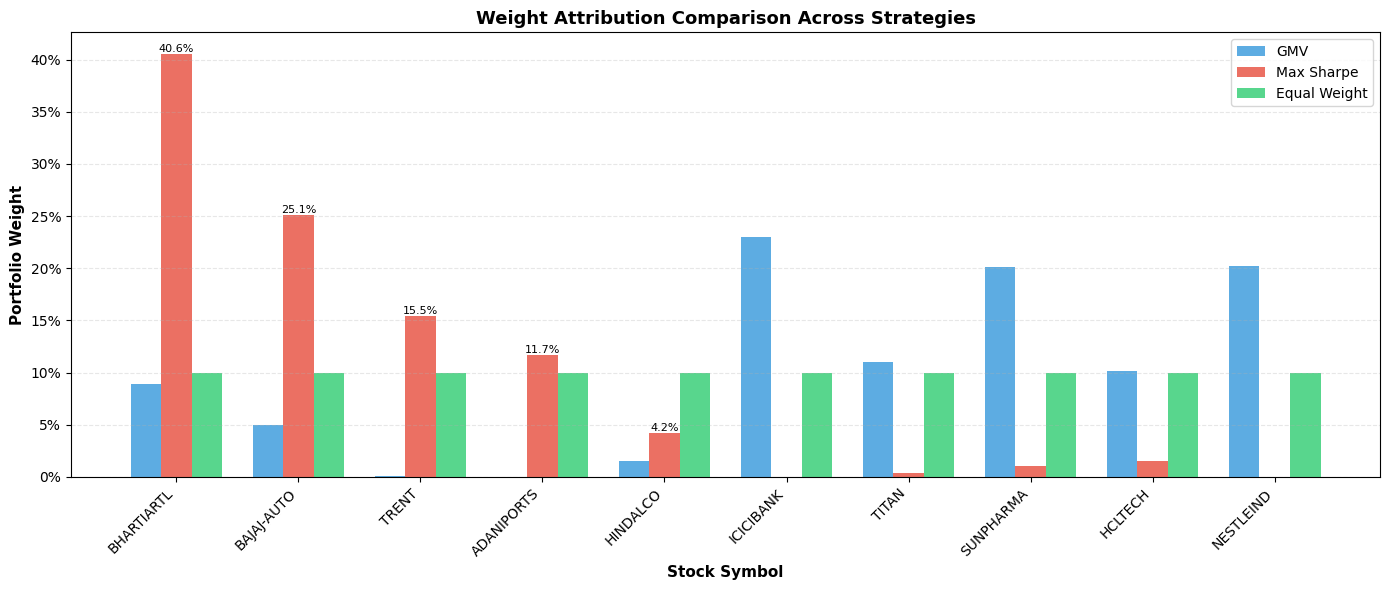


Weight Table:


,GMV,MaxSharpe,EqualWeight
BHARTIARTL,8.86%,40.59%,10.00%
BAJAJ-AUTO,4.95%,25.14%,10.00%
TRENT,0.13%,15.47%,10.00%
ADANIPORTS,0.00%,11.69%,10.00%
HINDALCO,1.53%,4.16%,10.00%
ICICIBANK,23.04%,0.03%,10.00%
TITAN,11.02%,0.34%,10.00%
SUNPHARMA,20.08%,1.00%,10.00%
HCLTECH,10.17%,1.57%,10.00%
NESTLEIND,20.24%,0.00%,10.00%


In [9]:
print("\n" + "="*80)
print("WEIGHT ATTRIBUTION ANALYSIS")
print("="*80)

weights_df = pd.concat([w_gmv, w_msr, w_eq], axis=1)

print("\nHerfindahl-Hirschman Index (HHI):")
for col in weights_df.columns:
    hhi = (weights_df[col] ** 2).sum()
    print(f"   {col:15s}: {hhi:.4f} (Effective N = {1/hhi:.2f})")

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(weights_df.index))
width = 0.25

bars1 = ax.bar(x - width, weights_df['GMV'], width, label='GMV', alpha=0.8, color='#3498db')
bars2 = ax.bar(x, weights_df['MaxSharpe'], width, label='Max Sharpe', alpha=0.8, color='#e74c3c')
bars3 = ax.bar(x + width, weights_df['EqualWeight'], width, label='Equal Weight', alpha=0.8, color='#2ecc71')

ax.set_xlabel('Stock Symbol', fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio Weight', fontsize=11, fontweight='bold')
ax.set_title('Weight Attribution Comparison Across Strategies', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(weights_df.index, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

for bar in bars2:
    height = bar.get_height()
    if height > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nWeight Table:")
display(weights_df.style
        .format('{:.2%}')
        .background_gradient(cmap='RdYlGn', axis=None)
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightcoral'))

In [10]:
print("\n" + "="*80)
print("BACKTEST ANALYSIS (IN-SAMPLE)")
print("="*80)

def calculate_portfolio_returns(returns_df, weights):
    return (returns_df @ weights).rename(weights.name)

port_gmv = calculate_portfolio_returns(R_selected, w_gmv)
port_msr = calculate_portfolio_returns(R_selected, w_msr)
port_eq = calculate_portfolio_returns(R_selected, w_eq)

portfolio_returns = pd.concat([port_gmv, port_msr, port_eq], axis=1)

def calculate_performance_metrics(returns, rf_annual=RF_ANNUAL, trading_days=TRADING_DAYS):
    cumulative_return = (1 + returns).prod()
    n_years = len(returns) / trading_days
    annual_return = cumulative_return ** (1/n_years) - 1

    annual_vol = returns.std() * np.sqrt(trading_days)

    rf_daily = (1 + rf_annual) ** (1/trading_days) - 1
    excess_returns = returns - rf_daily
    sharpe = excess_returns.mean() / (returns.std() + 1e-12) * np.sqrt(trading_days)

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else 0
    sortino = excess_returns.mean() / (downside_std + 1e-12) * np.sqrt(trading_days)

    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    win_rate = (returns > 0).sum() / len(returns)

    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()

    return {
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Win Rate': win_rate,
        'VaR 95%': var_95 * np.sqrt(trading_days),
        'CVaR 95%': cvar_95 * np.sqrt(trading_days)
    }

metrics_df = pd.DataFrame({
    col: calculate_performance_metrics(portfolio_returns[col])
    for col in portfolio_returns.columns
}).T

metrics_display = metrics_df.copy()
for col in ['Annual Return', 'Annual Volatility', 'Max Drawdown', 'Win Rate', 'VaR 95%', 'CVaR 95%']:
    metrics_display[col] = metrics_display[col].apply(lambda x: f'{x:.2%}')
for col in ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']:
    metrics_display[col] = metrics_display[col].apply(lambda x: f'{x:.3f}')

display(metrics_display)


BACKTEST ANALYSIS (IN-SAMPLE)


,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Win Rate,VaR 95%,CVaR 95%
GMV,21.90%,11.20%,1.262,1.991,-16.51%,1.327,53.04%,-16.69%,-23.24%
MaxSharpe,42.85%,16.71%,1.843,2.627,-25.15%,1.703,56.56%,-22.68%,-35.30%
EqualWeight,31.11%,13.40%,1.619,2.346,-20.88%,1.490,54.94%,-18.86%,-28.46%
